#  FIFA World Cup 2026 — Match Score Prediction
**Notebook 05 of 05**



## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
from pathlib import Path
from scipy.stats import poisson
from scipy.optimize import minimize
from itertools import product

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE_DIR  = Path('')
RAW_DIR   = BASE_DIR / 'data' / 'raw'
PROC_DIR  = BASE_DIR / 'data' / 'processed'
MODEL_DIR = BASE_DIR / 'models'

# ── Load reusable data ───────────────────────────────────────────
df_results  = pd.read_csv(RAW_DIR  / 'results.csv', parse_dates=['date'])
df_fixtures = pd.read_csv(RAW_DIR  / 'wc_2026_fixtures.csv', parse_dates=['date'])
df_teams    = pd.read_csv(RAW_DIR  / 'wc_2026_teams.csv')
df_h2h      = pd.read_csv(PROC_DIR / 'h2h_records.csv')
df_elo      = pd.read_csv(PROC_DIR / 'elo_all_teams.csv')
df_features = pd.read_csv(PROC_DIR / 'features_all_matches.csv', parse_dates=['date'])

# Drop future/unplayed matches
df_played = df_results.dropna(subset=['home_score','away_score']).copy()
df_played = df_played.sort_values('date').reset_index(drop=True)

with open(MODEL_DIR / 'models.pkl', 'rb') as f:
    saved = pickle.load(f)

final_ensemble = saved['final_ensemble']
FEATURE_COLS   = saved['feature_cols']
DRAW_THRESHOLD = saved['draw_threshold']

WC26_TEAMS = df_teams['team'].tolist()
elo_lookup  = dict(zip(df_elo['team'], df_elo['elo']))
AVG_ELO     = np.mean(list(elo_lookup.values()))

print(f'✅ Data loaded')
print(f'   Played matches : {len(df_played):,}')
print(f'   WC 2026 teams  : {len(WC26_TEAMS)}')
print(f'   Group fixtures : {len(df_fixtures[df_fixtures["stage"] == "Group"])}')
print(f'   Features       : {len(df_features):,}')
print(f'   H2H records    : {len(df_h2h):,}')
print(f'   Feature cols   : {len(FEATURE_COLS)}')
print(f'   Draw threshold : {DRAW_THRESHOLD:.2f}')

✅ Data loaded
   Played matches : 49,417
   WC 2026 teams  : 48
   Group fixtures : 72
   Features       : 31,783
   H2H records    : 2,256
   Feature cols   : 41
   Draw threshold : 0.29


---
## 1. Build Training Dataset for Goal Model

We use **recent international matches** (post-2018) to compute attack/defense ratings.
Recency matters more here than in the win/loss model — team scoring patterns change over time.

In [2]:
CUTOFF_DATE = '2018-01-01'

df_train = df_played[
    (df_played['date'] >= CUTOFF_DATE) &
    (~df_played['tournament'].str.contains('Friendly', case=False, na=False))
].copy()

# Recency weights — exponential decay, ~1 year half-life
max_date = df_train['date'].max()
df_train['days_ago']       = (max_date - df_train['date']).dt.days
df_train['recency_weight'] = np.exp(-df_train['days_ago'] / 365)

# Tournament importance weights
def tournament_weight(t):
    if 'World Cup' in t and 'Qualification' not in t: return 2.0
    if 'Qualification' in t or 'Nations' in t:        return 1.5
    return 1.0

df_train['tournament_weight'] = df_train['tournament'].apply(tournament_weight)
df_train['weight']            = df_train['recency_weight'] * df_train['tournament_weight']

print(f'Training matches (post-2018, no friendlies): {len(df_train):,}')
print(f'Date range : {df_train["date"].min().date()} → {df_train["date"].max().date()}')
print(f'Avg goals  : {(df_train["home_score"] + df_train["away_score"]).mean():.2f}')
print(f'Avg home   : {df_train["home_score"].mean():.2f}')
print(f'Avg away   : {df_train["away_score"].mean():.2f}')

Training matches (post-2018, no friendlies): 5,848
Date range : 2018-01-02 → 2026-06-14
Avg goals  : 2.79
Avg home   : 1.62
Avg away   : 1.17


---
## 2. Dixon-Coles Attack / Defense Rating System

Each team gets two parameters:
- **Attack (α)** — how many goals they tend to score
- **Defense (β)** — how many goals they tend to concede (lower = better)

Plus a global **home advantage (γ)** parameter.

Expected goals: `λ_home = exp(α_home - β_away + γ)`  
Expected goals: `λ_away = exp(α_away - β_home)`

In [3]:
all_teams_in_train  = sorted(set(
    df_train['home_team'].tolist() + df_train['away_team'].tolist()
))

wc_teams_in_train   = [t for t in WC26_TEAMS if t in all_teams_in_train]
missing_from_train  = [t for t in WC26_TEAMS if t not in all_teams_in_train]

print(f'WC 2026 teams in training data : {len(wc_teams_in_train)}')
print(f'Missing from training data     : {missing_from_train}')

# Filter to matches involving at least one WC 2026 team
wc_set = set(WC26_TEAMS)
df_train_wc = df_train[
    df_train['home_team'].isin(wc_set) | df_train['away_team'].isin(wc_set)
].copy().reset_index(drop=True)

MODEL_TEAMS = sorted(set(
    df_train_wc['home_team'].tolist() + df_train_wc['away_team'].tolist()
))
team_idx = {t: i for i, t in enumerate(MODEL_TEAMS)}
N_TEAMS  = len(MODEL_TEAMS)

print(f'\nFiltered matches (involve WC 2026 team): {len(df_train_wc):,}')
print(f'Total teams in model                   : {N_TEAMS}')

WC 2026 teams in training data : 48
Missing from training data     : []

Filtered matches (involve WC 2026 team): 2,617
Total teams in model                   : 205


In [4]:
from scipy.special import gammaln

# Validate all teams are in index before building arrays
missing_home = set(df_train_wc['home_team']) - set(MODEL_TEAMS)
missing_away = set(df_train_wc['away_team']) - set(MODEL_TEAMS)
if missing_home or missing_away:
    raise ValueError(f"Teams missing from index — home: {missing_home}  away: {missing_away}")

home_idx   = np.array([team_idx[t] for t in df_train_wc['home_team']], dtype=np.int32)
away_idx   = np.array([team_idx[t] for t in df_train_wc['away_team']], dtype=np.int32)
home_goals = df_train_wc['home_score'].values.astype(np.int32)
away_goals = df_train_wc['away_score'].values.astype(np.int32)
weights    = df_train_wc['weight'].values
neutral    = df_train_wc['neutral'].values.astype(bool)

log_fac_home = gammaln(home_goals + 1)
log_fac_away = gammaln(away_goals + 1)

def dc_log_likelihood(params):
    alpha = params[:N_TEAMS]
    beta  = params[N_TEAMS:2*N_TEAMS]
    gamma = params[2*N_TEAMS]
    rho   = params[2*N_TEAMS + 1]

    g_home = np.where(neutral, 0.0, gamma)

    lambda_home = np.exp(alpha[home_idx] - beta[away_idx] + g_home)
    lambda_away = np.exp(alpha[away_idx] - beta[home_idx])

    dc_mask_00 = (home_goals == 0) & (away_goals == 0)
    dc_mask_10 = (home_goals == 1) & (away_goals == 0)
    dc_mask_01 = (home_goals == 0) & (away_goals == 1)
    dc_mask_11 = (home_goals == 1) & (away_goals == 1)

    tau = np.ones(len(home_goals))
    tau[dc_mask_00] = 1 - lambda_home[dc_mask_00] * lambda_away[dc_mask_00] * rho
    tau[dc_mask_10] = 1 + lambda_away[dc_mask_10] * rho
    tau[dc_mask_01] = 1 + lambda_home[dc_mask_01] * rho
    tau[dc_mask_11] = 1 - rho

    # Clip tau to avoid log(0)
    tau = np.clip(tau, 1e-10, None)

    ll_home = home_goals * np.log(lambda_home) - lambda_home - log_fac_home
    ll_away = away_goals * np.log(lambda_away) - lambda_away - log_fac_away

    return -np.dot(weights, ll_home + ll_away + np.log(tau))

x0 = np.zeros(2 * N_TEAMS + 2)
x0[2 * N_TEAMS]     = 0.25   # home advantage initial guess
x0[2 * N_TEAMS + 1] = -0.1   # rho initial guess

constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x[:N_TEAMS])}]

print(f'⚙️  Fitting Dixon-Coles model...')
print(f'   {N_TEAMS} teams × 2 params + home_advantage + rho = {2*N_TEAMS+2} parameters')

result = minimize(
    dc_log_likelihood,
    x0,
    method='SLSQP',
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-9}
)

fitted_params  = result.x
attack_params  = fitted_params[:N_TEAMS]
defense_params = fitted_params[N_TEAMS:2*N_TEAMS]
home_advantage = fitted_params[2*N_TEAMS]
fitted_rho     = fitted_params[2*N_TEAMS + 1]

print(f'✅ Optimization complete')
print(f'   Converged     : {result.success}')
print(f'   Final log-lik : {-result.fun:.2f}')
print(f'   Home advantage: {home_advantage:.4f}  '
      f'(≈ {np.exp(home_advantage):.3f}x goal multiplier)')
print(f'   Fitted rho    : {fitted_rho:.4f}')

if not result.success:
    print(f'⚠️  Optimization did not converge — results may be unreliable')
    print(f'   Message: {result.message}')

⚙️  Fitting Dixon-Coles model...
   205 teams × 2 params + home_advantage + rho = 412 parameters
✅ Optimization complete
   Converged     : True
   Final log-lik : -1259.36
   Home advantage: 0.2552  (≈ 1.291x goal multiplier)
   Fitted rho    : -0.1576


# result

In [5]:
df_ratings = pd.DataFrame({
    'team':    MODEL_TEAMS,
    'attack':  attack_params,
    'defense': defense_params,
})

df_ratings['elo']          = df_ratings['team'].map(elo_lookup)
df_ratings['attack_rank']  = df_ratings['attack'].rank(ascending=False).astype(int)
# Lower beta = harder to score against = better defense
df_ratings['defense_rank'] = df_ratings['defense'].rank(ascending=True).astype(int)

df_ratings = df_ratings.sort_values('attack', ascending=False).reset_index(drop=True)
df_ratings.to_csv(PROC_DIR / 'attack_defense_ratings.csv', index=False)

wc_ratings = df_ratings[df_ratings['team'].isin(WC26_TEAMS)].copy()

print('Top 15 WC 2026 teams by attack rating:')
display(wc_ratings.sort_values('attack', ascending=False).head(15)[[
    'team', 'attack', 'defense', 'elo', 'attack_rank', 'defense_rank'
]].round(4).reset_index(drop=True))

print('\nTop 15 WC 2026 teams by defense rating (lower beta = better):')
display(wc_ratings.sort_values('defense', ascending=True).head(15)[[
    'team', 'attack', 'defense', 'elo', 'attack_rank', 'defense_rank'
]].round(4).reset_index(drop=True))

Top 15 WC 2026 teams by attack rating:


,team,attack,defense,elo,attack_rank,defense_rank
0,Norway,2.9979,2.1080,1799.5497,2,165
1,Germany,2.9569,2.2342,1896.9211,3,174
2,England,2.9502,3.2917,1921.7785,4,205
3,Spain,2.9439,2.5658,2048.1745,5,196
4,Netherlands,2.7658,2.3279,1880.8989,7,179
5,Portugal,2.7387,2.3437,1933.1183,8,180
6,Japan,2.6611,2.4360,1885.5403,10,189
7,Sweden,2.6298,1.6526,1715.4585,11,108
8,France,2.6252,2.4979,1973.4012,12,193
9,Belgium,2.5967,1.7785,1815.8304,13,125



Top 15 WC 2026 teams by defense rating (lower beta = better):


,team,attack,defense,elo,attack_rank,defense_rank
0,Curaçao,1.7481,1.1847,1551.1974,86,53
1,Tunisia,2.0250,1.3383,1635.1148,53,68
2,Cape Verde,1.7974,1.3417,1594.0197,82,70
3,Haiti,1.6711,1.4429,1624.8569,87,82
4,New Zealand,2.0404,1.6289,1642.2181,50,102
5,South Africa,1.9055,1.6353,1628.1382,68,104
6,Sweden,2.6298,1.6526,1715.4585,11,108
7,Qatar,1.9094,1.6906,1623.3813,66,112
8,Algeria,2.3471,1.7635,1801.6347,29,120
9,Belgium,2.5967,1.7785,1815.8304,13,125


---
## 3. Scoreline Prediction Engine

Given any two teams, compute the full probability distribution over all scorelines (0-0 to 6-6).

In [6]:
# Discover features the ensemble expects
ENSEMBLE_FEATURES = FEATURE_COLS  # already loaded from models.pkl — use directly

# Verify ensemble has matching feature expectations
if hasattr(final_ensemble, 'feature_names_in_'):
    stored = list(final_ensemble.feature_names_in_)
    if stored != FEATURE_COLS:
        print(f'⚠️  Feature mismatch — ensemble expects {len(stored)}, FEATURE_COLS has {len(FEATURE_COLS)}')
    else:
        print(f'✅ Feature alignment confirmed: {len(FEATURE_COLS)} features')
elif hasattr(final_ensemble, 'estimators_'):
    for est_name, est in final_ensemble.named_estimators_.items():
        if hasattr(est, 'feature_names_in_'):
            print(f'   {est_name}: {len(est.feature_names_in_)} features')

print(f'ENSEMBLE_FEATURES: {len(ENSEMBLE_FEATURES)} features')

✅ Feature alignment confirmed: 41 features
ENSEMBLE_FEATURES: 41 features


In [7]:
from scipy.stats import poisson
import numpy as np

# ── Lookups ──────────────────────────────────────────────────────
attack_lookup  = dict(zip(df_ratings['team'], df_ratings['attack']))
defense_lookup = dict(zip(df_ratings['team'], df_ratings['defense']))
DEFAULT_ATTACK  = 0.0
DEFAULT_DEFENSE = float(np.mean(defense_params))
MAX_GOALS       = 8

# Match training labels: 0=Away, 1=Draw, 2=Home
CLASS_MAP = {0: 'away', 1: 'draw', 2: 'home'}

# ── H2H lookup using correct column names ────────────────────────
def get_h2h_adjustment(home, away, weight=0.05):
    r = df_h2h[(df_h2h['team_a'] == home) & (df_h2h['team_b'] == away)]
    if len(r) == 0:
        return 0.0
    row = r.iloc[0]
    if row['games'] == 0:
        return 0.0
    win_rate = float(row['a_win_rate_weighted']) if pd.notna(row['a_win_rate_weighted']) else 0.5
    return weight * (win_rate - 0.5)

# ── Expected goals from Dixon-Coles ─────────────────────────────
def expected_goals(home, away, neutral=True, elo_weight=0.0, h2h_weight=0.0):
    a_home = attack_lookup.get(home,  DEFAULT_ATTACK)
    d_home = defense_lookup.get(home, DEFAULT_DEFENSE)
    a_away = attack_lookup.get(away,  DEFAULT_ATTACK)
    d_away = defense_lookup.get(away, DEFAULT_DEFENSE)

    h_adv  = 0.0 if neutral else home_advantage
    log_lh = a_home - d_away + h_adv
    log_la = a_away - d_home

    if elo_weight:
        adj    = elo_weight * (elo_lookup.get(home, AVG_ELO) - elo_lookup.get(away, AVG_ELO)) / 400.0
        log_lh += adj
        log_la -= adj
    if h2h_weight:
        adj    = get_h2h_adjustment(home, away, weight=h2h_weight)
        log_lh += adj
        log_la -= adj

    return np.exp(log_lh), np.exp(log_la)

# ── Scoreline probability matrix ─────────────────────────────────
def scoreline_probs(home, away, neutral=True, rho=None, max_goals=MAX_GOALS, **kw):
    if rho is None:
        rho = fitted_rho
    lh, la = expected_goals(home, away, neutral, **kw)

    i = np.arange(max_goals)
    m = np.outer(poisson.pmf(i, lh), poisson.pmf(i, la))

    m[0, 0] *= 1 - lh * la * rho
    m[1, 0] *= 1 + la * rho
    m[0, 1] *= 1 + lh * rho
    m[1, 1] *= 1 - rho

    np.clip(m, 0.0, None, out=m)
    m /= m.sum()
    return m, lh, la

# ── Team form from raw played matches ───────────────────────────
def _team_form(team, n, as_of=None):
    g = df_played if as_of is None else df_played[df_played['date'] < as_of]
    g = g[(g['home_team'] == team) | (g['away_team'] == team)]
    g = g.dropna(subset=['home_score', 'away_score']).sort_values('date').tail(n)
    if len(g) == 0:
        return {'win_rate': 0.5, 'gf': 1.0, 'ga': 1.0, 'gd': 0.0}
    is_home = g['home_team'] == team
    gf = np.where(is_home, g['home_score'], g['away_score']).astype(float)
    ga = np.where(is_home, g['away_score'], g['home_score']).astype(float)
    return {
        'win_rate': float((gf > ga).mean()),
        'gf':       float(gf.mean()),
        'ga':       float(ga.mean()),
        'gd':       float((gf - ga).mean()),
    }

# ── Build ensemble features matching FEATURE_COLS exactly ────────
def build_ensemble_features(home, away, neutral=True, as_of=None):
    h3  = _team_form(home,  3, as_of)
    h5  = _team_form(home,  5, as_of)
    h10 = _team_form(home, 10, as_of)
    a3  = _team_form(away,  3, as_of)
    a5  = _team_form(away,  5, as_of)
    a10 = _team_form(away, 10, as_of)

    he = elo_lookup.get(home, AVG_ELO)
    ae = elo_lookup.get(away, AVG_ELO)

    # FIFA rank — from df_teams
    h_rank = dict(zip(df_teams['team'], df_teams['fifa_rank'])).get(home, 100)
    a_rank = dict(zip(df_teams['team'], df_teams['fifa_rank'])).get(away, 100)

    # H2H from df_h2h
    r = df_h2h[(df_h2h['team_a'] == home) & (df_h2h['team_b'] == away)]
    if len(r):
        h2h_row = r.iloc[0]
        h2h_games    = int(h2h_row['games'])
        h2h_home_wins= int(h2h_row['a_wins'])
        h2h_away_wins= int(h2h_row['b_wins'])
        h2h_wr_w     = float(h2h_row['a_win_rate_weighted']) \
                       if pd.notna(h2h_row['a_win_rate_weighted']) else 0.5
    else:
        h2h_games = 0
        h2h_home_wins = 0
        h2h_away_wins = 0
        h2h_wr_w      = 0.5

    row = {
        # ELO
        'home_elo_before':  he,
        'away_elo_before':  ae,
        'elo_diff':         he - ae,
        # Rank
        'home_elo_rank':    h_rank,
        'away_elo_rank':    a_rank,
        'rank_diff':        h_rank - a_rank,
        # Form 3
        'home_win_rate_3':  h3['win_rate'],
        'away_win_rate_3':  a3['win_rate'],
        'win_rate_diff_3':  h3['win_rate'] - a3['win_rate'],
        'home_avg_gf_3':    h3['gf'],
        'home_avg_ga_3':    h3['ga'],
        'home_avg_gd_3':    h3['gd'],
        'away_avg_gf_3':    a3['gf'],
        'away_avg_ga_3':    a3['ga'],
        'away_avg_gd_3':    a3['gd'],
        'gd_diff_3':        h3['gd'] - a3['gd'],
        # Form 5
        'home_win_rate_5':  h5['win_rate'],
        'away_win_rate_5':  a5['win_rate'],
        'win_rate_diff_5':  h5['win_rate'] - a5['win_rate'],
        'home_avg_gf_5':    h5['gf'],
        'home_avg_ga_5':    h5['ga'],
        'home_avg_gd_5':    h5['gd'],
        'away_avg_gf_5':    a5['gf'],
        'away_avg_ga_5':    a5['ga'],
        'away_avg_gd_5':    a5['gd'],
        'gd_diff_5':        h5['gd'] - a5['gd'],
        # Form 10
        'home_win_rate_10': h10['win_rate'],
        'away_win_rate_10': a10['win_rate'],
        'win_rate_diff_10': h10['win_rate'] - a10['win_rate'],
        'home_avg_gf_10':   h10['gf'],
        'home_avg_ga_10':   h10['ga'],
        'home_avg_gd_10':   h10['gd'],
        'away_avg_gf_10':   a10['gf'],
        'away_avg_ga_10':   a10['ga'],
        'away_avg_gd_10':   a10['gd'],
        'gd_diff_10':       h10['gd'] - a10['gd'],
        # H2H
        'h2h_games':           h2h_games,
        'h2h_home_wins':       h2h_home_wins,
        'h2h_away_wins':       h2h_away_wins,
        'h2h_home_win_rate_w': h2h_wr_w,
        # Context
        'is_neutral': int(neutral),
    }

    return pd.DataFrame([row]).reindex(columns=FEATURE_COLS)

# ── Ensemble WDL probabilities ───────────────────────────────────
def _ensemble_wdl(home, away, neutral=True, as_of=None):
    X = build_ensemble_features(home, away, neutral, as_of)
    nan_cols = X.columns[X.isna().any()].tolist()
    if nan_cols:
        print(f'⚠️  Ensemble skipped for {home} vs {away} — NaN in: {nan_cols}')
        return None
    proba = final_ensemble.predict_proba(X)[0]
    out = {'home': 0.0, 'draw': 0.0, 'away': 0.0}
    for c, p in zip(final_ensemble.classes_, proba):
        out[CLASS_MAP[c]] += float(p)
    return out

# ── Rescale matrix to match blended WDL ─────────────────────────
def _rescale_to_wdl(m, p_home, p_draw, p_away):
    out = m.copy()
    n   = m.shape[0]
    L   = np.tril(np.ones((n, n)), -1).astype(bool)
    D   = np.eye(n, dtype=bool)
    U   = np.triu(np.ones((n, n)), 1).astype(bool)
    for mask, target in ((L, p_home), (D, p_draw), (U, p_away)):
        cur = out[mask].sum()
        if cur > 0:
            out[mask] *= target / cur
    out /= out.sum()
    return out

# ── Main prediction function ─────────────────────────────────────
def predict_match(home, away, neutral=True, top_n=5, stage='group',
                  blend_ensemble=True, elo_weight=0.0, h2h_weight=0.0,
                  as_of=None):

    rho = fitted_rho
    if stage == 'knockout':
        rho = max(min(fitted_rho * 1.15, 0.0), -0.18)

    matrix, lh, la = scoreline_probs(home, away, neutral, rho=rho,
                                     elo_weight=elo_weight, h2h_weight=h2h_weight)
    mg = matrix.shape[0]

    p_home_win = float(np.tril(matrix, -1).sum())
    p_draw     = float(np.diag(matrix).sum())
    p_away_win = float(np.triu(matrix, 1).sum())

    if blend_ensemble:
        try:
            ens = _ensemble_wdl(home, away, neutral, as_of)
            if ens is not None:
                a_dc, a_en = 0.6, 0.4
                p_home_win = a_dc * p_home_win + a_en * ens['home']
                p_draw     = a_dc * p_draw     + a_en * ens['draw']
                p_away_win = a_dc * p_away_win + a_en * ens['away']
                s = p_home_win + p_draw + p_away_win
                p_home_win /= s
                p_draw     /= s
                p_away_win /= s
                matrix = _rescale_to_wdl(matrix, p_home_win, p_draw, p_away_win)
        except Exception as e:
            print(f'⚠️  Ensemble blend skipped: {e}')

    flat = sorted(
        [(i, j, matrix[i][j]) for i in range(mg) for j in range(mg)],
        key=lambda x: -x[2]
    )
    top_scorelines = [
        (f"{home} {i}-{j} {away}", round(p * 100, 2))
        for i, j, p in flat[:top_n]
    ]

    goals_grid = np.add.outer(np.arange(mg), np.arange(mg))
    p_over25   = round(float(matrix[goals_grid > 2].sum())  * 100, 2)
    p_under25  = round(float(matrix[goals_grid <= 2].sum()) * 100, 2)
    p_btts     = round(
        (1 - matrix[0, :].sum() - matrix[:, 0].sum() + matrix[0, 0]) * 100, 2
    )
    p_home_cs  = round(float(matrix[:, 0].sum()) * 100, 2)
    p_away_cs  = round(float(matrix[0, :].sum()) * 100, 2)

    return {
        'home': home, 'away': away,
        'xg_home':        round(lh, 3),
        'xg_away':        round(la, 3),
        'p_home_win':     round(p_home_win * 100, 2),
        'p_draw':         round(p_draw     * 100, 2),
        'p_away_win':     round(p_away_win * 100, 2),
        'top_scorelines': top_scorelines,
        'p_over25':       p_over25,
        'p_under25':      p_under25,
        'p_btts':         p_btts,
        'p_home_cs':      p_home_cs,
        'p_away_cs':      p_away_cs,
        'scoreline_matrix': matrix,
    }

# ── Sanity check ─────────────────────────────────────────────────
test = predict_match('Spain', 'Morocco', stage='group')
print('Spain vs Morocco')
print(f"  xG     : Spain {test['xg_home']} — Morocco {test['xg_away']}")
print(f"  Result : Spain {test['p_home_win']}%  "
      f"Draw {test['p_draw']}%  Morocco {test['p_away_win']}%")
print('  Top scorelines:')
for score, pct in test['top_scorelines']:
    print(f'    {score}  →  {pct}%')
print(f"  Over 2.5 : {test['p_over25']}%   BTTS : {test['p_btts']}%")
print(f"  Fitted rho: {fitted_rho:.4f}")

Spain vs Morocco
  xG     : Spain 1.194 — Morocco 0.834
  Result : Spain 43.63%  Draw 36.71%  Morocco 19.66%
  Top scorelines:
    Spain 0-0 Morocco  →  16.42%
    Spain 1-1 Morocco  →  16.36%
    Spain 1-0 Morocco  →  14.08%
    Spain 2-0 Morocco  →  9.68%
    Spain 2-1 Morocco  →  8.07%
  Over 2.5 : 32.25%   BTTS : 41.95%
  Fitted rho: -0.1576


---
## 4. Predict All 72 Group Stage Matches

In [8]:
group_fixtures  = df_fixtures[df_fixtures['stage'] == 'Group'].copy()
all_predictions = []

for _, fix in group_fixtures.iterrows():
    home, away = fix['home'], fix['away']

    # Warn if team missing from DC ratings
    for t in [home, away]:
        if t not in attack_lookup:
            print(f'⚠️  {t} missing from DC ratings — using defaults')

    pred = predict_match(home, away, neutral=True)
    mat  = pred['scoreline_matrix']
    gh = round(pred['xg_home'])
    ga = round(pred['xg_away'])

    all_predictions.append({
        'match_id':        fix['match_id'],
        'date':            fix['date'],
        'group':           fix['group'],
        'home_team':       home,
        'away_team':       away,
        'xg_home':         pred['xg_home'],
        'xg_away':         pred['xg_away'],
        'predicted_score': f'{gh}-{ga}',
        'pred_home_goals': gh,
        'pred_away_goals': ga,
        'p_home_win':      pred['p_home_win'],
        'p_draw':          pred['p_draw'],
        'p_away_win':      pred['p_away_win'],
        'p_over25':        pred['p_over25'],
        'p_under25':       pred['p_under25'],
        'p_btts':          pred['p_btts'],
        'p_home_cs':       pred['p_home_cs'],
        'p_away_cs':       pred['p_away_cs'],
        'top1_score':      pred['top_scorelines'][0][0],
        'top1_pct':        pred['top_scorelines'][0][1],
        'top2_score':      pred['top_scorelines'][1][0],
        'top2_pct':        pred['top_scorelines'][1][1],
        'top3_score':      pred['top_scorelines'][2][0],
        'top3_pct':        pred['top_scorelines'][2][1],
        'top4_score':      pred['top_scorelines'][3][0],
        'top4_pct':        pred['top_scorelines'][3][1],
        'top5_score':      pred['top_scorelines'][4][0],
        'top5_pct':        pred['top_scorelines'][4][1],
    })

df_predictions = pd.DataFrame(all_predictions)
df_predictions.to_csv(PROC_DIR / 'wc2026_scoreline_predictions.csv', index=False)
print(f'✅ Saved {len(df_predictions)} match predictions')
display(df_predictions[[
    'home_team', 'away_team', 'xg_home', 'xg_away',
    'predicted_score', 'p_home_win', 'p_draw', 'p_away_win',
    'p_over25', 'p_btts'
]].head(12))

✅ Saved 72 match predictions


,home_team,away_team,xg_home,xg_away,predicted_score,p_home_win,p_draw,p_away_win,p_over25,p_btts
0,Mexico,South Africa,1.676,0.382,2-0,72.52,21.27,6.21,35.35,26.21
1,South Korea,Czech Republic,1.901,0.978,2-1,59.33,24.57,16.10,55.28,54.41
2,Czech Republic,South Africa,2.014,1.095,2-1,49.05,31.83,19.12,56.86,61.00
3,Mexico,South Korea,0.814,0.663,1-1,41.15,36.07,22.79,19.72,28.05
4,South Africa,South Korea,0.636,2.275,1-2,10.76,21.65,67.59,54.06,44.64
5,Czech Republic,Mexico,0.587,1.401,1-1,27.76,25.52,46.72,33.06,34.84
6,Canada,Bosnia and Herzegovina,1.242,1.002,1-1,42.68,36.00,21.32,37.76,47.67
7,Qatar,Switzerland,0.623,2.321,1-2,11.81,24.57,63.62,52.90,45.46
8,Switzerland,Bosnia and Herzegovina,1.823,0.686,2-1,52.05,23.46,24.49,45.65,44.09
9,Canada,Qatar,1.581,0.909,2-1,65.58,20.77,13.65,48.91,46.97


---
## 5. Deep Dive — Individual Match Analysis

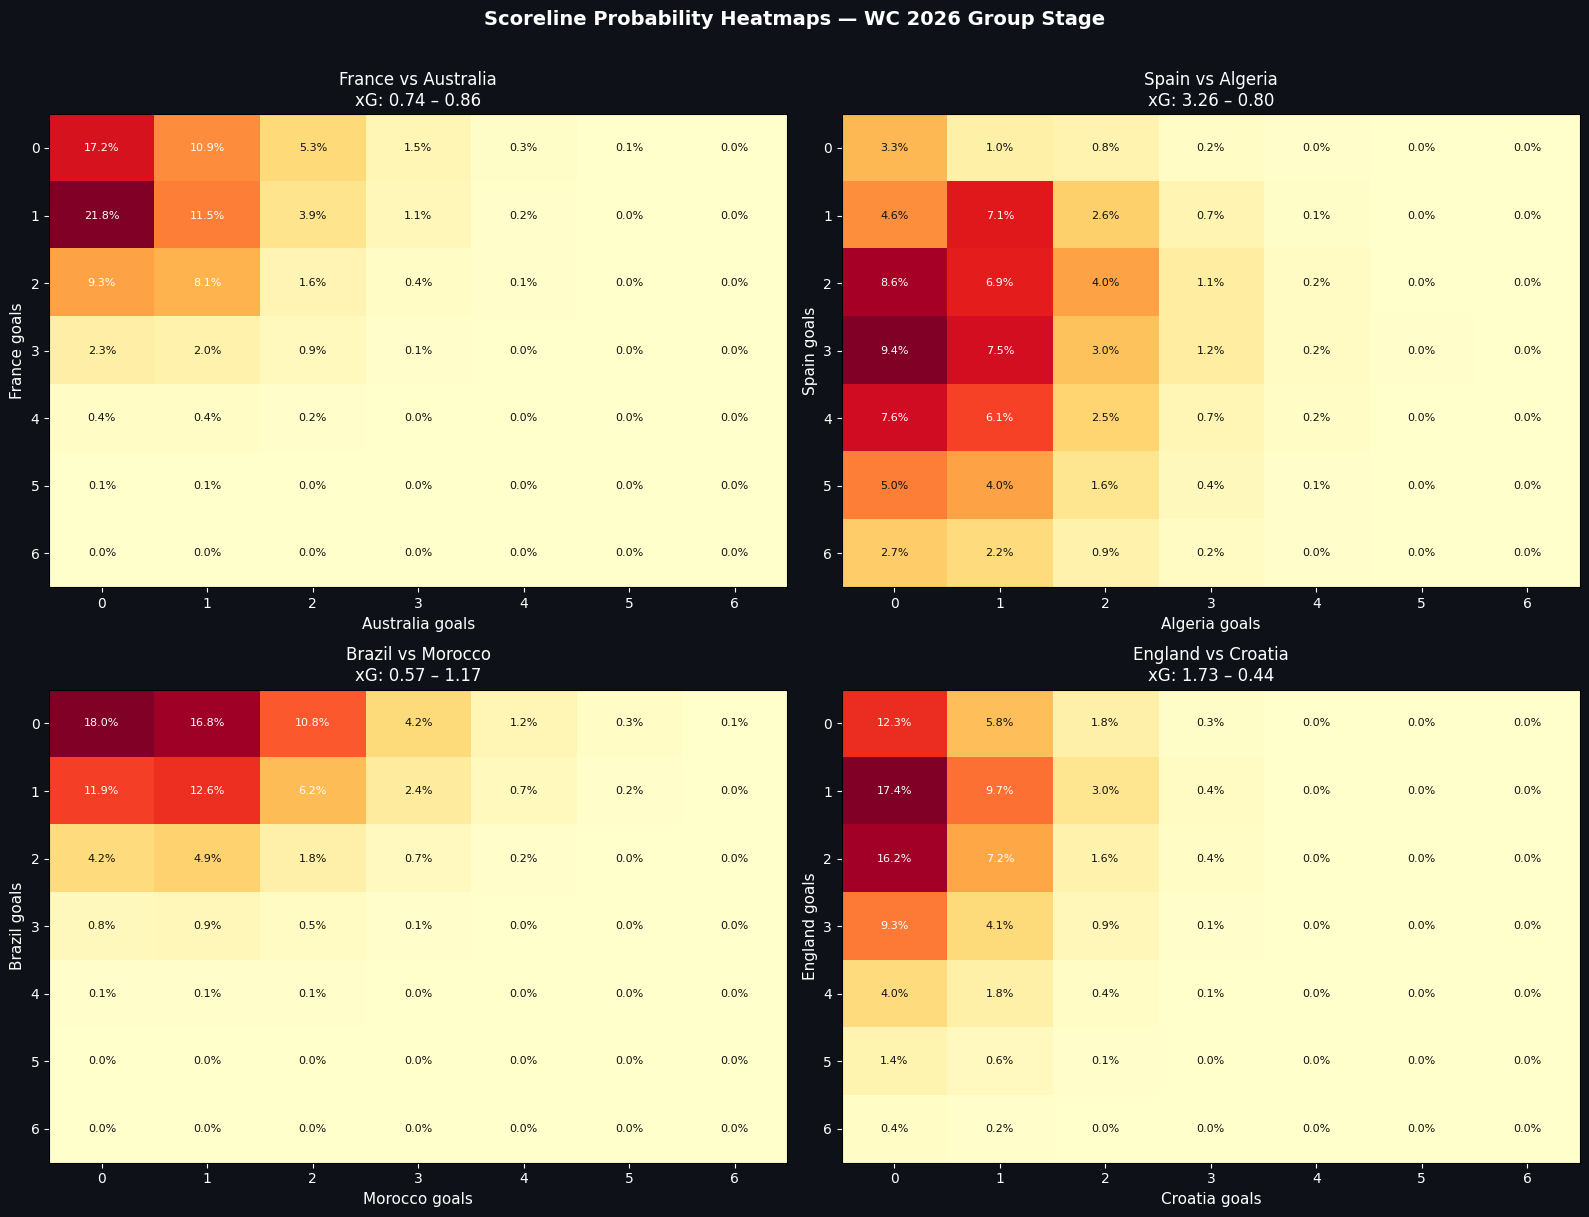

✅ Saved scoreline_heatmaps.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    'figure.facecolor': '#0e1117', 'axes.facecolor': '#0e1117',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
})

def plot_scoreline_heatmap(home, away, ax=None):
    pred   = predict_match(home, away, neutral=True)
    matrix = pred['scoreline_matrix']
    lh, la = pred['xg_home'], pred['xg_away']
    show   = 7
    mat    = matrix[:show, :show]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(mat * 100, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(show))
    ax.set_yticks(range(show))
    ax.set_xticklabels(range(show))
    ax.set_yticklabels(range(show))
    ax.set_xlabel(f'{away} goals', fontsize=11)
    ax.set_ylabel(f'{home} goals', fontsize=11)
    ax.set_title(f'{home} vs {away}\nxG: {lh:.2f} – {la:.2f}',
                 fontsize=12, color='white')

    for i in range(show):
        for j in range(show):
            # dark cells (high prob) → white text; light cells → black text
            ax.text(j, i, f'{mat[i,j]*100:.1f}%',
                    ha='center', va='center', fontsize=8,
                    color='white' if mat[i, j] > 0.06 else '#111111')
    return ax


# Verify matchups exist in WC26_TEAMS before plotting
matchups = [
    ('France',  'Australia'),
    ('Spain',   'Algeria'),
    ('Brazil',  'Morocco'),
    ('England', 'Croatia'),
]
for home, away in matchups:
    for t in [home, away]:
        if t not in WC26_TEAMS:
            print(f'⚠️  {t} not in WC26_TEAMS — check team name spelling')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0e1117')
for ax, (home, away) in zip(axes.flat, matchups):
    plot_scoreline_heatmap(home, away, ax=ax)

plt.suptitle('Scoreline Probability Heatmaps — WC 2026 Group Stage',
             fontsize=14, fontweight='bold', y=1.01, color='white')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'scoreline_heatmaps.png', dpi=120,
            bbox_inches='tight', facecolor='#0e1117')
plt.show()
print('✅ Saved scoreline_heatmaps.png')

---
## 6. Group Summary — Expected Goals by Group

In [10]:
print('=' * 65)
print('WC 2026 GROUP STAGE — MATCH PREDICTIONS SUMMARY')
print('=' * 65)

for group in sorted(df_predictions['group'].unique()):
    grp = df_predictions[df_predictions['group'] == group]
    print(f'\nGroup {group}:')
    for _, row in grp.iterrows():
        print(f"  {row['home_team']:<25} vs {row['away_team']:<25} "
              f"| Predicted: {int(row['pred_home_goals'])}-{int(row['pred_away_goals'])} "
              f"| xG: {row['xg_home']:.2f}-{row['xg_away']:.2f} "
              f"| H:{row['p_home_win']:.0f}% D:{row['p_draw']:.0f}% A:{row['p_away_win']:.0f}%")

WC 2026 GROUP STAGE — MATCH PREDICTIONS SUMMARY

Group A:
  Mexico                    vs South Africa              | Predicted: 2-0 | xG: 1.68-0.38 | H:73% D:21% A:6%
  South Korea               vs Czech Republic            | Predicted: 2-1 | xG: 1.90-0.98 | H:59% D:25% A:16%
  Czech Republic            vs South Africa              | Predicted: 2-1 | xG: 2.01-1.09 | H:49% D:32% A:19%
  Mexico                    vs South Korea               | Predicted: 1-1 | xG: 0.81-0.66 | H:41% D:36% A:23%
  South Africa              vs South Korea               | Predicted: 1-2 | xG: 0.64-2.27 | H:11% D:22% A:68%
  Czech Republic            vs Mexico                    | Predicted: 1-1 | xG: 0.59-1.40 | H:28% D:26% A:47%

Group B:
  Canada                    vs Bosnia and Herzegovina    | Predicted: 1-1 | xG: 1.24-1.00 | H:43% D:36% A:21%
  Qatar                     vs Switzerland               | Predicted: 1-2 | xG: 0.62-2.32 | H:12% D:25% A:64%
  Switzerland               vs Bosnia and Herzegovina

---
## 7. Save Model

In [11]:
import os
poisson_model = {
    'attack':          attack_lookup,
    'defense':         defense_lookup,
    'home_advantage':  home_advantage,
    'rho':             fitted_rho,
    'default_attack':  DEFAULT_ATTACK,
    'default_defense': DEFAULT_DEFENSE,
    'max_goals':       MAX_GOALS,
    'elo_lookup':      elo_lookup,
    'avg_elo':         AVG_ELO,
}
with open(MODEL_DIR / 'poisson_model.pkl', 'wb') as f:
    pickle.dump(poisson_model, f)

# Verify reload
with open(MODEL_DIR / 'poisson_model.pkl', 'rb') as f:
    test_load = pickle.load(f)
assert set(poisson_model.keys()) == set(test_load.keys()), "Poisson model reload mismatch"

print('=' * 55)
print('SCORE PREDICTION — FILES SAVED')
print('=' * 55)
for fname in ['poisson_model.pkl', 'models.pkl', 'scoreline_heatmaps.png']:
    path = MODEL_DIR / fname
    if path.exists():
        print(f'  📦 models/{fname:<40} {os.path.getsize(path)/1024:.1f} KB')
    else:
        print(f'  ⚠️  models/{fname} — NOT FOUND')

for fname in ['attack_defense_ratings.csv', 'wc2026_scoreline_predictions.csv']:
    path = PROC_DIR / fname
    if path.exists():
        print(f'  📄 processed/{fname:<36} {os.path.getsize(path)/1024:.1f} KB')
    else:
        print(f'  ⚠️  processed/{fname} — NOT FOUND')

print('\n✅ Score prediction notebook complete')
print('   Next → dashboard integration')

SCORE PREDICTION — FILES SAVED
  📦 models/poisson_model.pkl                        15.4 KB
  📦 models/models.pkl                               119897.2 KB
  📦 models/scoreline_heatmaps.png                   159.4 KB
  📄 processed/attack_defense_ratings.csv           14.9 KB
  📄 processed/wc2026_scoreline_predictions.csv     17.0 KB

✅ Score prediction notebook complete
   Next → dashboard integration
